In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Task1

In [22]:
df = pd.read_csv("transactions.csv")
df.head()

,order_id,user_id,amount,date
0,1,101,120.50,2024-01-01
1,2,102,89.99,2024-01-02
2,3,103,45.00,2024-01-02
3,4,104,230.10,2024-01-03
4,5,105,15.75,2024-01-03


In [23]:
print(f"Nan count: \n{df.isna().sum()}")

Nan count: 
order_id    0
user_id     0
amount      2
date        0
dtype: int64


In [24]:
df.describe()

,order_id,user_id,amount
count,25.000000,25.000000,23.000000
mean,13.000000,113.000000,175.394783
std,7.359801,7.359801,233.797434
min,1.000000,101.000000,5.990000
25%,7.000000,107.000000,50.275000
50%,13.000000,113.000000,89.990000
75%,19.000000,119.000000,180.000000
max,25.000000,125.000000,999.990000


In [26]:
nan_arr = np.array(df["amount"])
not_nan_mask = ~np.isnan(nan_arr) 
arr = nan_arr[not_nan_mask]

print(f"Count: {len(arr)}")
print(f"Average: {arr.mean()}")
print(f"{np.median(arr)}")
print(f"{arr.min()}")
print(f"{arr.max()}")
print(f"{np.percentile(arr, 25)}")
print(f"{np.percentile(arr, 50)}")
print(f"{np.percentile(arr, 75)}")

Count: 23
Average: 175.39478260869564
89.99
5.99
999.99
50.275
89.99
180.0


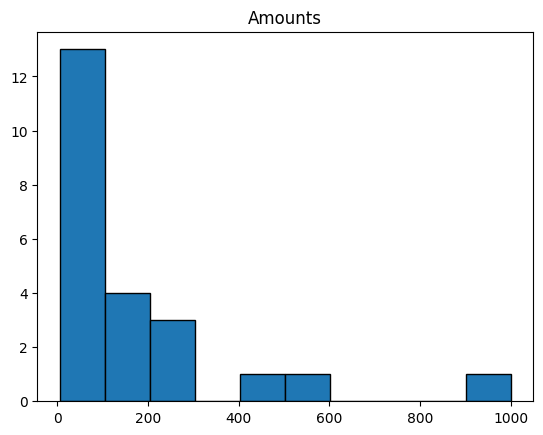

In [29]:
plt.hist(arr, edgecolor="black")
plt.title("Amounts")
plt.show()

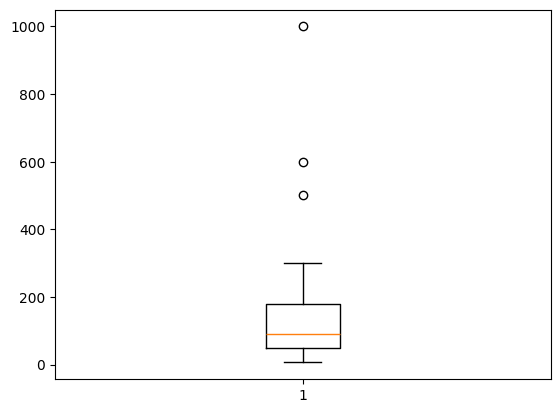

In [10]:
plt.boxplot(arr)
plt.title = "Amounts"
plt.show()

# Task2

In [11]:
arr2_1 = np.array([12, 500, 15, 22, 999, 18, 10])
arr2 = arr2_1.reshape((7, 1))
print(arr2)

[[ 12]
 [500]
 [ 15]
 [ 22]
 [999]
 [ 18]
 [ 10]]


In [18]:
q1 = np.percentile(arr2, 25)
q3 = np.percentile(arr2, 75)
iqr = q3 - q1

print(f"Average: {arr2.mean()}")
print(f"Median: {np.median(arr2)}")
print(f"Std: {arr2.std():.2f}")
print(f"IQR: {iqr}")
print(f"MAD: {stats.median_abs_deviation(arr2)}")
print(f"Skew: {stats.skew(arr2)} \nKurtosis: {stats.kurtosis(arr2)}")

Average: 225.14285714285714
Median: 18.0
Std: 357.46
IQR: 247.5
MAD: [6.]
Skew: [1.36989464] 
Kurtosis: [0.27261777]


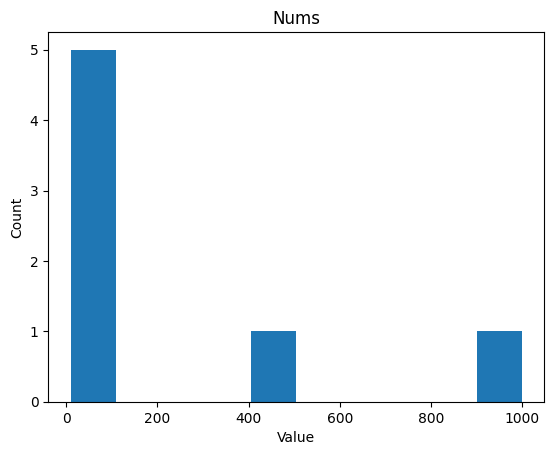

In [16]:
fig, ax = plt.subplots()
ax.hist(arr2)
ax.set_title("Nums")
ax.set_xlabel("Value")
ax.set_ylabel("Count")
plt.show()

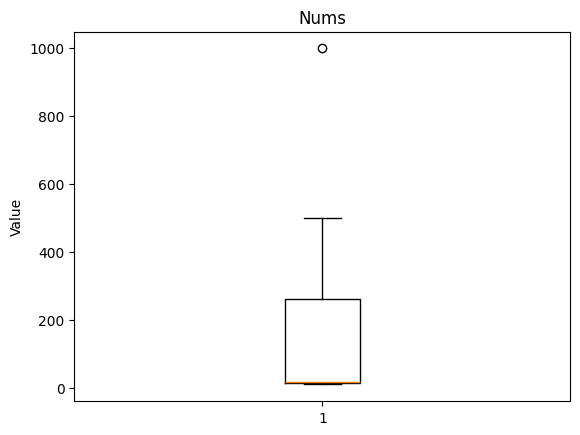

In [17]:
fig, ax = plt.subplots()
ax.boxplot(arr2)
ax.set_title("Nums")
ax.set_ylabel("Value")
plt.show()

In [23]:
x1 = q1 - 1.5 * iqr
x2 = q3 + 1.5 * iqr
outliers = arr2[(arr2 < x1) | (arr2 > x2)]
outlier_fraction = len(outliers) / len(df)
print(outlier_fraction)

0.04


# Task3

In [13]:
ratings = np.random.randint(1, 6, size=200)
counts = pd.DataFrame(ratings, columns=['rating'])
freq_table = counts['rating'].value_counts().sort_index().reset_index()
freq_table.columns = ['rating', 'frequency']
freq_table['relative_freq'] = freq_table['frequency'] / len(counts)
freq_table['cumulative_share'] = freq_table['relative_freq'].cumsum()

print(freq_table)

   rating  frequency  relative_freq  cumulative_share
0       1         41          0.205             0.205
1       2         43          0.215             0.420
2       3         43          0.215             0.635
3       4         39          0.195             0.830
4       5         34          0.170             1.000


In [8]:
mode_val = counts['rating'].mode()[0]
median_val = counts['rating'].median()
mean_val = counts['rating'].mean()
print(f"Mode: {mode_val}, Median: {median_val}, Average: {mean_val}")

Mode: 3, Median: 3.0, Average: 2.515


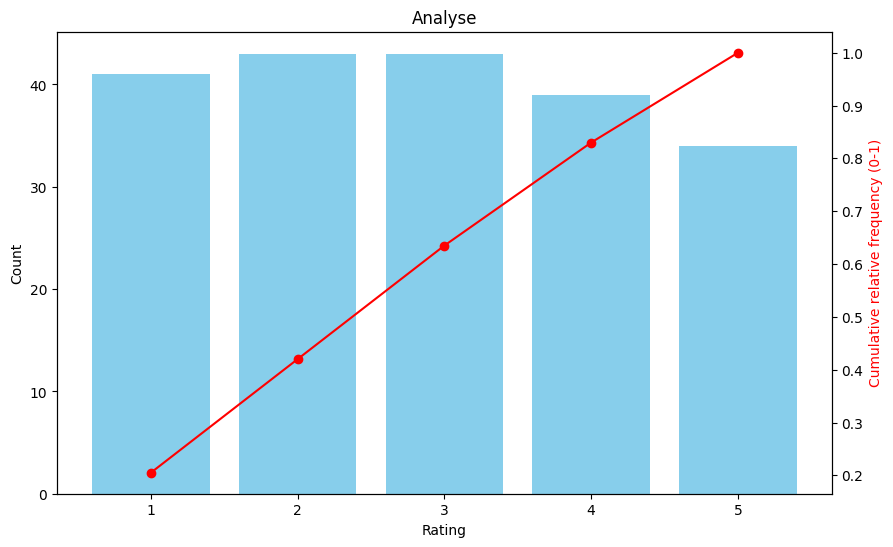

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(freq_table["rating"], freq_table["frequency"], color="skyblue", label="Frequency")
ax1.set_xlabel("Rating")
ax1.set_ylabel("Count")

ax2 = ax1.twinx()
ax2.plot(freq_table["rating"], freq_table["cumulative_share"], color="red", marker="o", label="Cumulative relative frequency")
ax2.set_ylabel("Cumulative relative frequency (0-1)", color="red")

plt.title("Analyse")
plt.show()

# Task4

In [16]:
np.random.seed(42)
height_data = np.random.normal(175, 10, 300)

height_data = np.append(height_data, [215, 130]) 
df_height = pd.DataFrame(height_data, columns=["height"])

percentiles = np.percentile(df_height["height"], [5, 25, 50, 75, 95])
perc_df = pd.DataFrame({"Percentile": [5, 25, 50, 75, 95], "Value": percentiles})

mean_h = df_height["height"].mean()
std_h = df_height["height"].std()
df_height["height_z"] = (df_height["height"] - mean_h) / std_h

outliers = df_height[df_height["height_z"].abs() > 3]
outliers_count = len(outliers)

df_height

,height,height_z
0,179.967142,0.484275
1,173.617357,-0.125996
2,181.476885,0.629375
3,190.230299,1.470656
4,172.658466,-0.218154
...,...,...
297,178.072995,0.302231
298,183.128621,0.788121
299,181.296288,0.612018
300,215.000000,3.851244


In [17]:
perc_df

,Percentile,Value
0,5,159.808562
1,25,168.103116
2,50,175.592195
3,75,181.286385
4,95,190.856766


In [18]:
print(f"\nNumber of outliers (|z| > 3): {outliers_count}")


Number of outliers (|z| > 3): 4


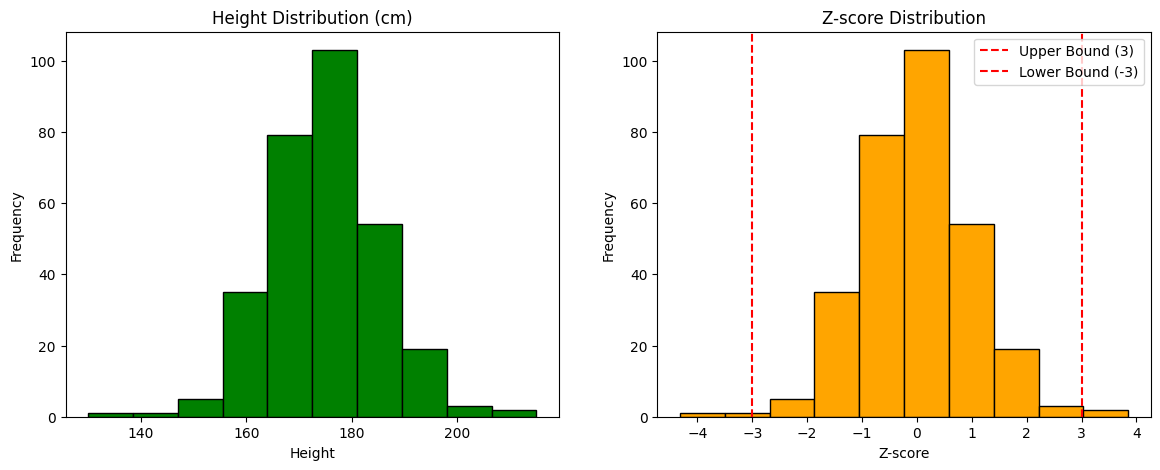

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df_height["height"], color="green", edgecolor="black")
ax1.set_title("Height Distribution (cm)")
ax1.set_xlabel("Height")
ax1.set_ylabel("Frequency")

ax2.hist(df_height["height_z"], color="orange", edgecolor="black")
ax2.set_title("Z-score Distribution")
ax2.set_xlabel("Z-score")
ax2.set_ylabel("Frequency")

ax2.axvline(3, color="red", linestyle="--", label="Upper Bound (3)") 
ax2.axvline(-3, color="red", linestyle="--", label="Lower Bound (-3)")
ax2.legend()

plt.show()